# Aufgabe 2

## Messen der Daten

Bei der zweiten Aufgabe, sollten wir die Resonanzkurve des Drehpendels bei einer Dämpfung messen, sowie die Phasenverschiebung zwischen der Anregung und Pendelscheibe. Da die Dämpfung über die Spule kommt und diese über den Strom am Channel 1 angesteuert wird, haben wir dort konstant 0.3 A eingestellt. Um herauszufinden, in welchem Bereich die Resonanzkurve circa ihren Peak hat, wurde zuerst in 1V Schritten zwischen 3V und 12V gemessen. Dabei ist aufgefallen, dass der Peak ungefähr bei 11V liegt, weshalb die eigentliche Messung zwischen 9V und 12V stattfand jeweils im Abstand von 0.1V.

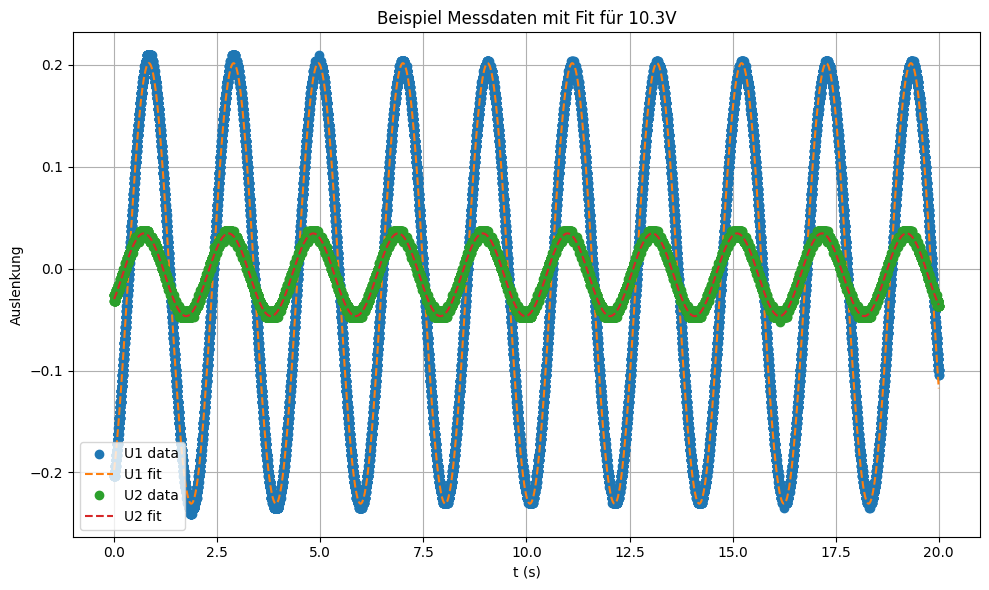

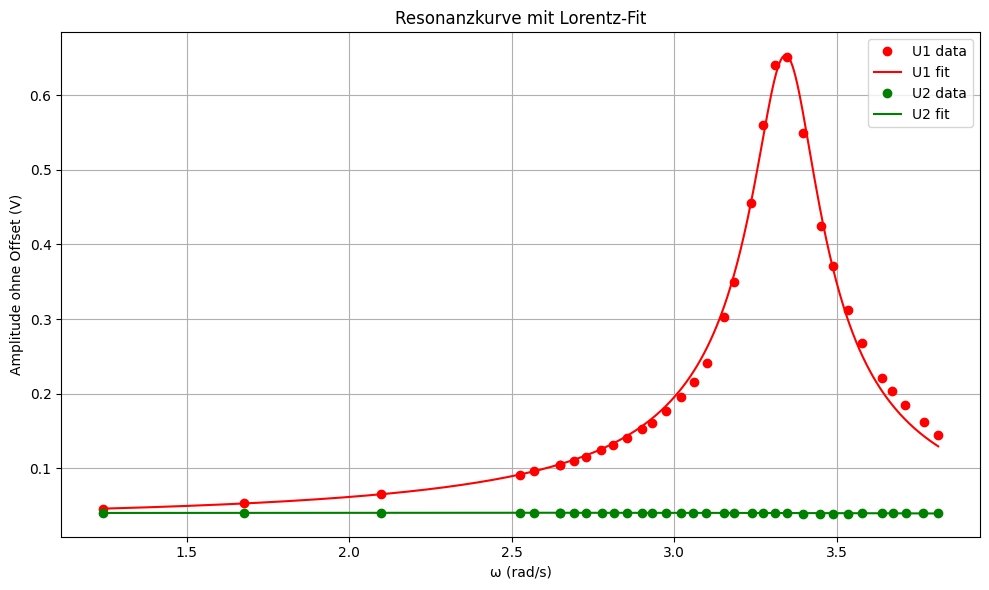

U1 fit parameters (A0, omega0, beta): [0.44465183 3.34567581 0.10175401]
U2 fit parameters (A0, omega0, beta): [1.55746405 6.23517342 4.05421847]


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from natsort import natsorted

# Sinusfunktion mit Offset
def sinus_function(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset

# Schätzfunktion für omega aus FFT
def estimate_omega_fft(x_data, y_data):
    dt = np.mean(np.diff(x_data))
    n = len(x_data)
    f = np.fft.fftfreq(n, d=dt)
    Y = np.fft.fft(y_data - np.mean(y_data))
    idx = np.argmax(np.abs(Y[1:n//2])) + 1  # überspringe 0-Frequenz
    freq = np.abs(f[idx])
    omega = 2 * np.pi * freq
    return omega

# Sinus fitten
def fit_sinus(x_data, y_data):
    A_guess = (np.max(y_data) - np.min(y_data)) / 2
    omega_guess = estimate_omega_fft(x_data, y_data)
    phase_guess = 0
    offset_guess = np.mean(y_data)
    p0 = [A_guess, omega_guess, phase_guess, offset_guess]
    params, params_covariance = curve_fit(
        sinus_function, x_data, y_data, p0=p0, maxfev=10000
    )
    fitted_y = sinus_function(x_data, *params)
    return params, fitted_y

# Lorentz-Funktion für Resonanzkurve
def lorentz_func(omega, A0, omega0, beta):
    return A0 / np.sqrt((omega0**2 - omega**2)**2 + (2*beta*omega)**2)

# Ordnerpfad anpassen
filepath = "M10_Aufgabe_2_CSV_Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

# Listen für Amplituden und Omegas
amplitudes_U1 = []
omegas_U1 = []
amplitudes_U2 = []
omegas_U2 = []
params_U1_Example = []
params_U2_Example = []
fitted_U1_Example = []
fitted_U2_Example = []
x_Example = 0
y_Example = 0
z_Example = 0

for filename in csv_files:
    df = pd.read_csv(os.path.join(filepath, filename))
    df.columns = ['t (s)', 'U1(V)', 'U2(V)']

    x = df['t (s)'].values
    y = df['U1(V)'].values
    z = df['U2(V)'].values

    if '10_3V_Aufgabe_2_daten.csv' in filename:
        paramsU2, fitted_U2 = fit_sinus(x, z)
        paramsU1 = [0.216, 3.06, -1.01, -0.0146]
        fitted_U1 = sinus_function(x, *paramsU1)
        params_U1_Example = paramsU1
        fitted_U1_Example = fitted_U1
        params_U2_Example = paramsU2
        fitted_U2_Example = fitted_U2
        x_Example = x
        y_Example = y
        z_Example = z
    else:
        paramsU1, fitted_U1 = fit_sinus(x, y)
        paramsU2, fitted_U2 = fit_sinus(x, z)

    # Speichere absolute Amplitude (ohne Offset)
    amplitudes_U1.append(np.abs(paramsU1[0]))
    omegas_U1.append(paramsU1[1])
    amplitudes_U2.append(np.abs(paramsU2[0]))
    omegas_U2.append(paramsU2[1])

# Plotten
plt.figure(figsize=(10, 6))
plt.plot(x_Example, y_Example, 'o', label='U1 data')
plt.plot(x_Example, fitted_U1_Example, '--', label='U1 fit')
plt.plot(x_Example, z_Example, 'o', label='U2 data')
plt.plot(x_Example, fitted_U2_Example, '--', label='U2 fit')
plt.xlabel('t (s)')
plt.ylabel('Auslenkung')
plt.title('Beispiel Messdaten mit Fit für 10.3V')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Arrays und Sortierung
omegas_U1 = np.array(omegas_U1)
amplitudes_U1 = np.array(amplitudes_U1)
sorted_indices_U1 = np.argsort(omegas_U1)
omegas_U1 = omegas_U1[sorted_indices_U1]
amplitudes_U1 = amplitudes_U1[sorted_indices_U1]

omegas_U2 = np.array(omegas_U2)
amplitudes_U2 = np.array(amplitudes_U2)
sorted_indices_U2 = np.argsort(omegas_U2)
omegas_U2 = omegas_U2[sorted_indices_U2]
amplitudes_U2 = amplitudes_U2[sorted_indices_U2]

# Fit der Resonanzkurve U1
p0 = [np.max(amplitudes_U1), omegas_U1[np.argmax(amplitudes_U1)], 0.1]
params_U1, _ = curve_fit(lorentz_func, omegas_U1, amplitudes_U1, p0=p0, maxfev=10000)
fit_omegas = np.linspace(np.min(omegas_U1), np.max(omegas_U1), 500)
fit_amplitudes_U1 = lorentz_func(fit_omegas, *params_U1)

# Fit der Resonanzkurve U2
p0 = [np.max(amplitudes_U2), omegas_U2[np.argmax(amplitudes_U2)], 0.1]
params_U2, _ = curve_fit(lorentz_func, omegas_U2, amplitudes_U2, p0=p0, maxfev=10000)
fit_amplitudes_U2 = lorentz_func(fit_omegas, *params_U2)

# Plotten
plt.figure(figsize=(10, 6))
plt.plot(omegas_U1, amplitudes_U1, 'ro', label='U1 data')
plt.plot(fit_omegas, fit_amplitudes_U1, 'r-', label='U1 fit')
plt.plot(omegas_U2, amplitudes_U2, 'go', label='U2 data')
plt.plot(fit_omegas, fit_amplitudes_U2, 'g-', label='U2 fit')
plt.xlabel('ω (rad/s)')
plt.ylabel('Amplitude ohne Offset (V)')
plt.title('Resonanzkurve mit Lorentz-Fit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Fit-Parameter ausgeben
print("U1 fit parameters (A0, omega0, beta):", params_U1)
print("U2 fit parameters (A0, omega0, beta):", params_U2)
